In [1]:
import Kea
from Kea.utils import plotting, funcs
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

D = 2
N = 256
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

In [2]:
amin, amax = -(D+3.), -1.
NUM = 10
alphas = np.linspace(amax, amin, NUM)
np.random.seed(1234)
fields = []
models = []

BREAK = 15 * dk

for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), gfunc='exp_pow', func_kwargs={'breaks': (BREAK,)}))

energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))

models = []
Pspecs = []
Aspecs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    kmesh = spectra_base.wavenumber_mesh(kD)

    _km, _fekm, width = statistics_base.bin_data(kmesh, fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    Pspecs.append((_km, _fekm))

    fekD_model = funcs.exp_pow(kmesh, (alphas[i],), (BREAK,))
    var = np.nansum(fekD_model * (dk/twopi)**D)
    fekD_model = fekD_model / var
    k_model, fek_model, w = statistics_base.bin_data(kmesh, fekD_model,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    models.append((k_model, fek_model))

    lags = arevalo_spectra.k_to_discrete_lags(_km, N, L)
    km, fekm = arevalo_spectra.modal_spectrum(f, lenn=phys_dims, lags=lags, mode='wrap')
    Aspecs.append((km, fekm))

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: divide by zero encountered in true_divide
  pl = np.exp(-bb/xx) * xx**(a1)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: divide by zero encountered in reciprocal
  pl = np.exp(-bb/xx) * xx**(a1)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: invalid value encountered in multiply
  pl = np.exp(-bb/xx) * xx**(a1)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: divide by zero encountered in power
  pl = np.exp(-bb/xx) * xx**(a1)
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: divide by zero encountered in true_divide
  pl = np.exp(-bb/xx) * xx**(a1)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: divide by zero enc

In [3]:
cols = plt.get_cmap('Greys')(np.linspace(0.25, 1., NUM))
cols2 = plt.cm.Blues(np.linspace(0.25, 1., NUM))
cols3 = plt.cm.Greens(np.linspace(0.25, 1., NUM))
upper_cmap = mpl.colors.LinearSegmentedColormap.from_list('Upper', cols2)

Text(0.5, 0, 'Wavenumber, $k$')

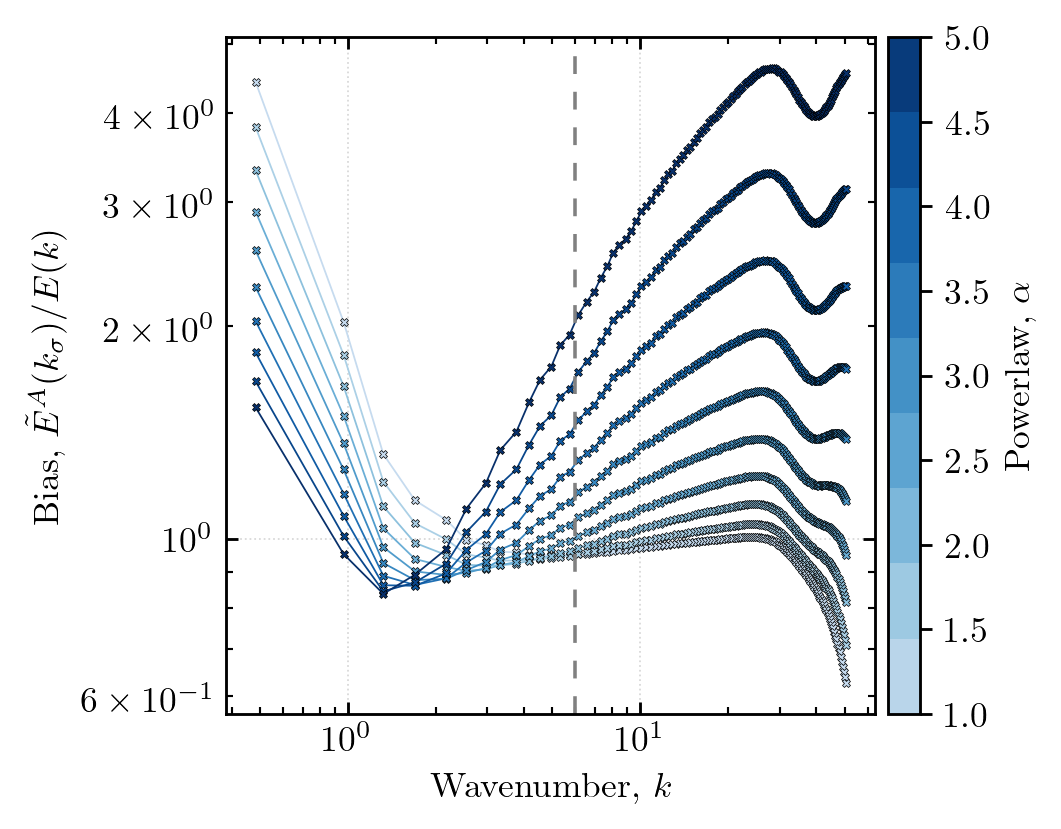

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

bias = []

for i in range(len(Aspecs)):
    pk, pfek = Pspecs[i]
    ak, afek = Aspecs[i]
    ax.plot(ak, afek / pfek, color=cols2[i], linewidth=0.5, marker='X', markersize=2.5, zorder=2, markeredgewidth=0.2, markeredgecolor='black')
    bias.append((ak, afek/pfek))

ax.set_yscale('log')
ax.set_xscale('log')

ax.axvline(BREAK, linestyle=(0,(5,5)), linewidth=1., color='gray')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

sm = plt.cm.ScalarMappable(cmap=upper_cmap, norm=mpl.colors.Normalize(-amax, -amin))
cbar = fig.colorbar(sm, cax=cax, boundaries=np.linspace(-amax, -amin, NUM), ticks=np.arange(-amax, -amin+1., 0.5))

cbar.ax.set_ylabel('Powerlaw, $\\alpha$')

ax.set_ylabel('Bias, $\\tilde{E}^A(k_\sigma)/E(k)$')
ax.set_xlabel('Wavenumber, $k$')

Text(0.5, 0, 'Wavenumber, $k$')

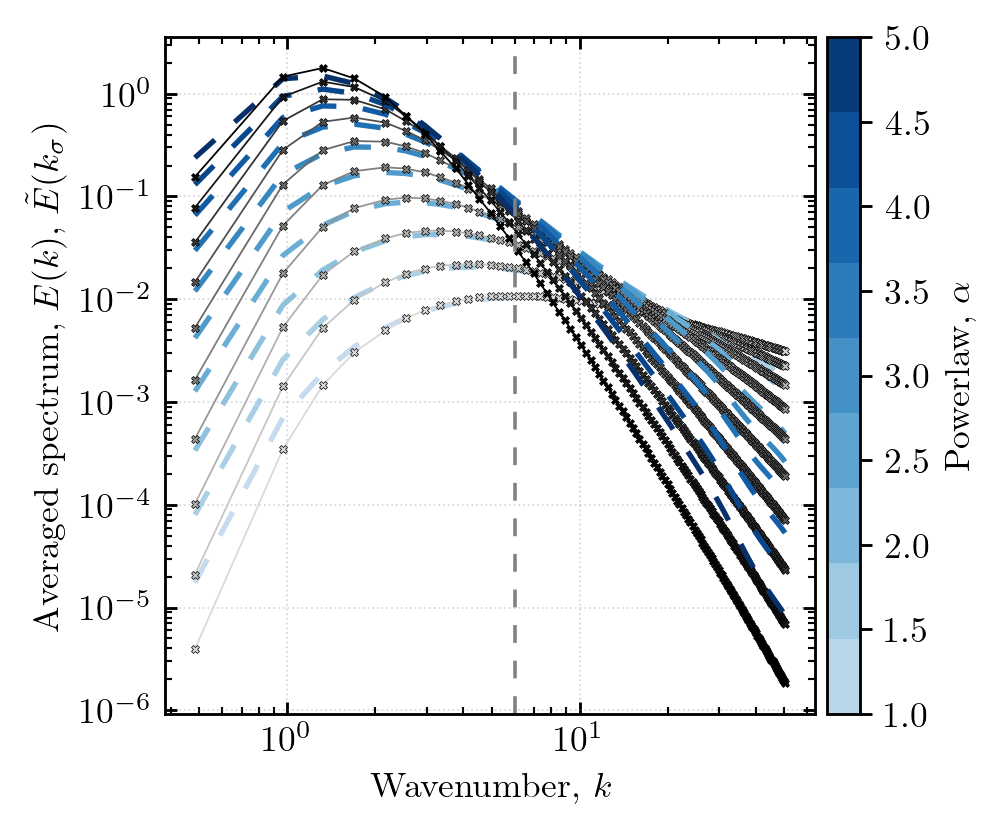

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

bias = []

for i in range(len(Aspecs)):
    pk, pfek = Pspecs[i]
    ak, afek = Aspecs[i]
    ax.loglog(ak, afek, color=cols2[i], linestyle=(0, (5,5)))
    ax.loglog(pk, pfek, color=cols[i], linewidth=0.5, marker='X', markersize=2.5, zorder=2, markeredgewidth=0.2, markeredgecolor='black')
    #bias.append((ak, afek/pfek))

ax.axvline(BREAK, linestyle=(0,(5,5)), linewidth=1., color='gray')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

sm = plt.cm.ScalarMappable(cmap=upper_cmap, norm=mpl.colors.Normalize(-amax, -amin))
cbar = fig.colorbar(sm, cax=cax, boundaries=np.linspace(-amax, -amin, NUM), ticks=np.arange(-amax, -amin+1., 0.5))

cbar.ax.set_ylabel('Powerlaw, $\\alpha$')

ax.set_ylabel('Averaged spectrum, $E(k)$, $\\tilde{E}(k_\sigma)$')
ax.set_xlabel('Wavenumber, $k$')

In [6]:
# IDX = 13

# from scipy.special import jv
# import sympy as sp
# sp.init_printing(use_latex='mathjax')

# k = sp.symbols('k', postive=True, real=True)

# sp_L = sp.symbols('L', positive=True, real=True)
# sp_L = sp.S(L)

# a1 = sp.S(3) #-alphas[IDX]
# #a = sp.symbols('a', postive=True, real=True)

# sp_kmin = sp.S(2*sp.pi/sp_L)
# sp_kmax = sp.S(sp.pi*N/sp_L)

# sp_break = sp.S(15 * sp_kmin)

# sp_E = sp.Piecewise(
#     (sp.S(0), k < sp_kmin),
#     (sp.S(0), k > sp_kmax),
#     #(sp.exp(sp_break/k)*k**(-a), True)
#     ((k**4)*((sp.S(1) + (k**2))**(-sp.Rational(17,6))), True)
# )

# display(sp_E)

# lim_min = sp_kmin
# lim_max = sp_kmax

# sig = sp.integrate(sp.S(2) * (sp.S(2) * sp.pi * k * sp_E) / (sp.S(2)*sp.pi)**2, (k, lim_min, lim_max))
# Ef = sp_E / sig

# s = sp.symbols('s', real=True, positive=True)
# xi = sp.symbols('xi', real=True, positive=True)

# Hk = k**2 * s**2 * xi * sp.exp(- k**2 * s**2 / 2)

# display(Hk)

# from scipy.special import gamma as G

# S_D = 2.*sp.pi**(D/2)/G(D/2)
# norm = 1./(2.*sp.pi)**D

# print('num')
# Vs_num = 2. * norm * sp.integrate((S_D * k**(D-1)) * Ef * sp.Abs(Hk)**2, (k, lim_min, lim_max))
# display(Vs_num)
# print('denom')
# Vs_denom = 2. * norm * sp.integrate((S_D * k**(D-1)) * sp.Abs(Hk)**2, (k, lim_min, lim_max))
# Vs = Vs_num / Vs_denom

# display(Vs_num)
# display(Vs_denom)
# display(Vs)


In [7]:
# lam_E = sp.lambdify(k, Ef, modules=['scipy', 'numpy'])
# lam_V = sp.lambdify(s, Vs.subs({xi: 1e-3, sp_L: L}), modules=['scipy', 'numpy'])
# for _k in np.linspace(2.*np.pi/L, np.pi*N/L, 100):
#     _s = np.sqrt(2.) / _k
#     num = lam_V(_s)
#     denom = lam_E(_k)
#     plt.scatter(_k, num/denom, marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

# plt.loglog(bias[IDX][0], bias[IDX][1])

# plt.loglog()

# plt.axvline(2.*np.pi/L, color='black', linewidth=1., linestyle=(0,(5,5)))
# plt.axvline(np.pi*N/L, color='black', linewidth=1., linestyle=(0,(5,5)))